# ЛР 3.4: Деревья решений

## Теоретическая часть

### Задача классификации

Text(0, 0.5, 'X2')

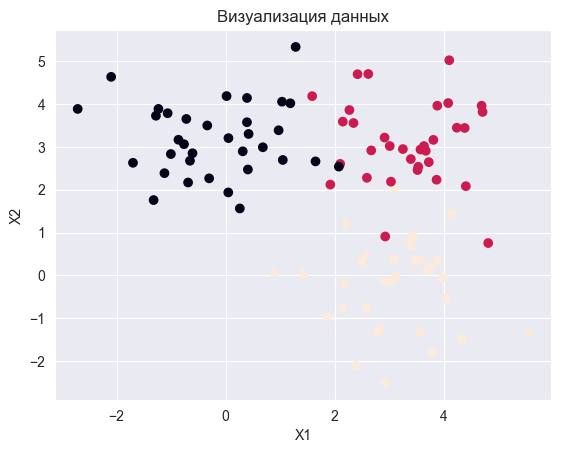

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs



X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)],
                                      n_features=2, random_state=35,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

## Создаем модель дерева и задаем ей глубину и обучаем

In [10]:
depth = 4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth,
                                  random_state=43)
clf_tree.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,43
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


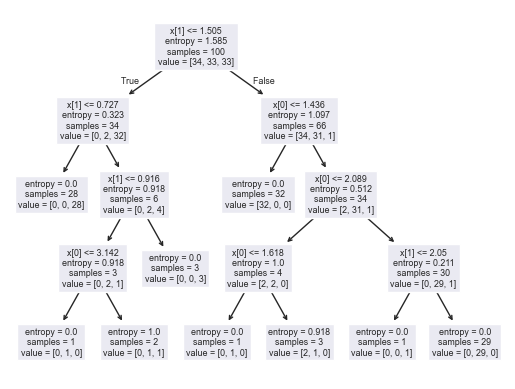

In [11]:
plot_tree(clf_tree)
plt.show()

## Визаулизация модели

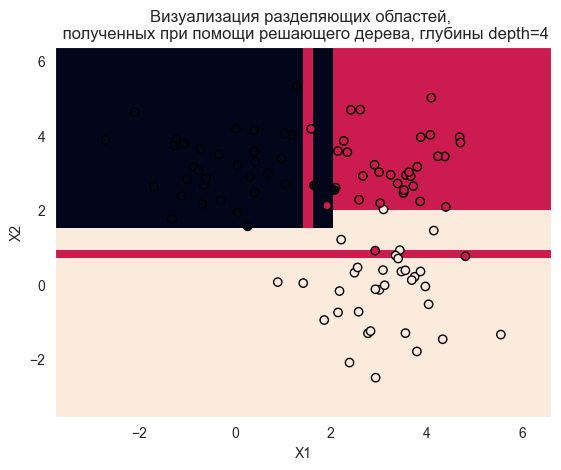

In [12]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Метрики

In [13]:
y_pred = clf_tree.predict(X)
print('Точность =', accuracy_score(y, y_pred))
print('F1 =', f1_score(y, y_pred, average='micro'))

Точность = 0.98
F1 = 0.98


<Axes: >

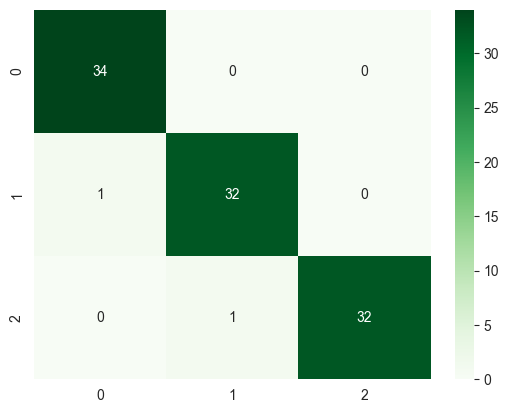

In [14]:
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Greens') # Оси y = true; x = predicted
# TP - FP
# TN - FN

## Создание новой точки

In [15]:
observation_new = [[2, 1]]
y_new = clf_tree.predict(observation_new)
print(*y_new)

2


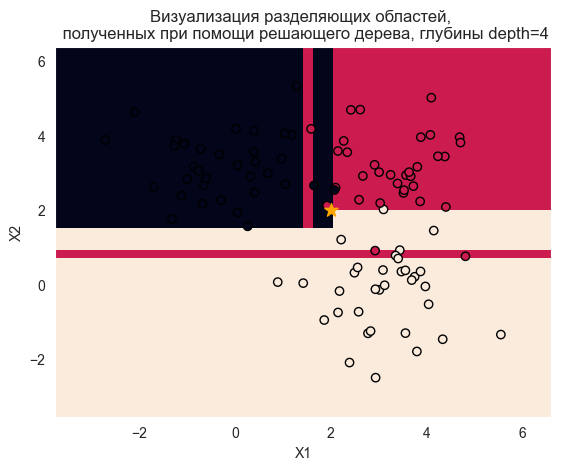

In [16]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.scatter(observation_new[0][0], y_new, marker='*', s=100, color='orange')
plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

### Задача регрессии

In [17]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

## Визуализируем датасет

Text(0, 0.5, 'X2')

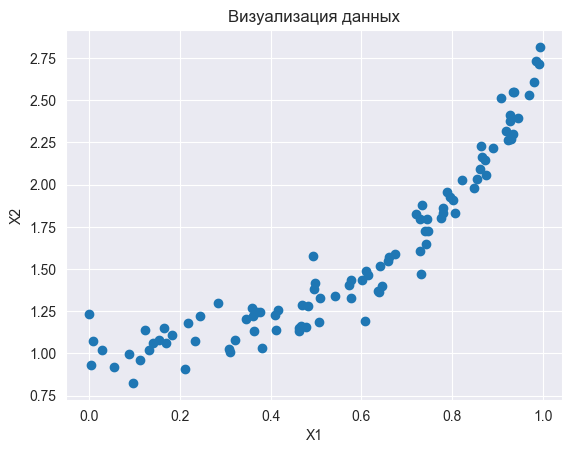

In [18]:
plt.scatter(X, y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

## Создание модели дерева регрессии с заданием глубины и обучение ее

In [19]:
X = np.sort(np.random.rand(n_samples)).reshape(-1, 1)
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0]).reshape(-1, 1)


depth=3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=25)
reg_tree.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


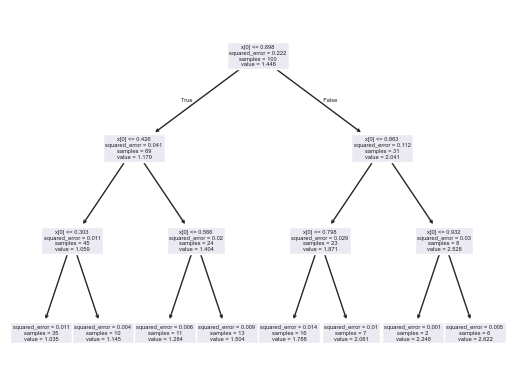

In [20]:
plot_tree(reg_tree)
plt.show()

## Линия регрессии модели на датасете

Text(0, 0.5, 'y')

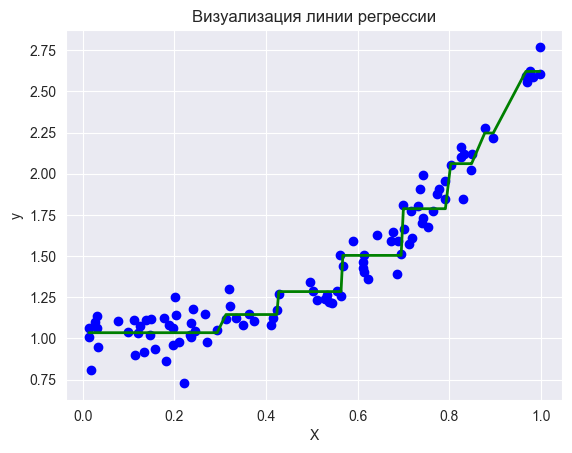

In [21]:
y_pred_reg = reg_tree.predict(X)

plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

## Метрики

In [22]:
print('R2  =', round(r2_score(y, y_pred_reg), 4))
print('MSE =', round(mean_squared_error(y, y_pred_reg), 4))

R2  = 0.9583
MSE = 0.0093


## Создание новой точки

In [23]:
observation_new = [[0.7]]
y_n = reg_tree.predict(observation_new)
print(y_new)

[2]


## Визуализация

Text(0, 0.5, 'y')

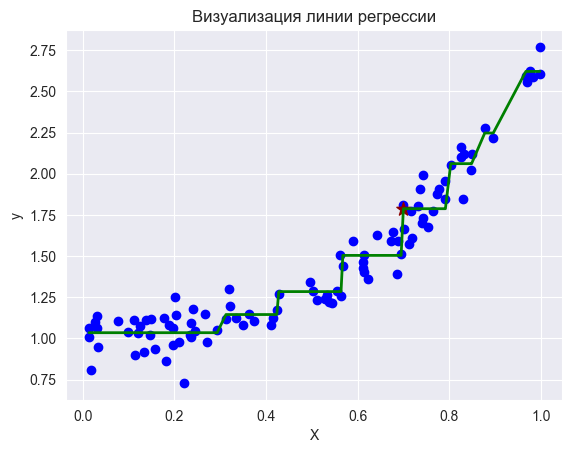

In [24]:
y_pred_reg = reg_tree.predict(X)

plt.scatter(X, y, c="b")
plt.scatter(observation_new[0], y_n, marker='*', s=100, color='darkred')
plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

# =======================================================================================

# **Самостоятельные задания**

## 1. Загрузка и визуализация датасета с рисом

['setosa' 'versicolor' 'virginica']


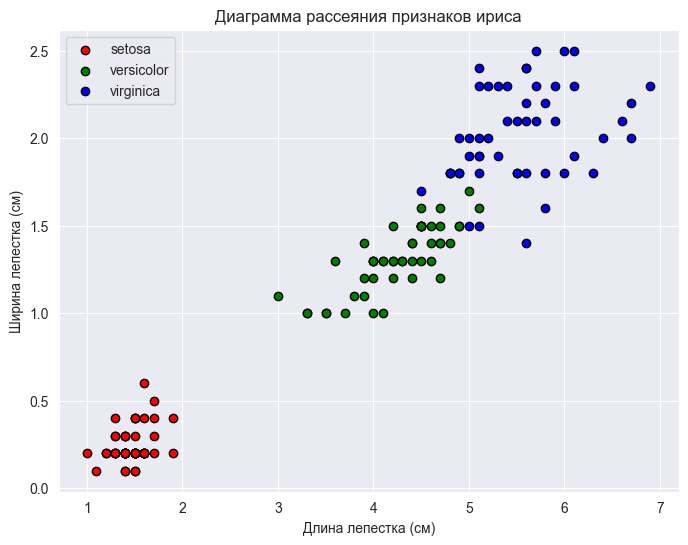

In [25]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Загружаем данные
iris = load_iris()

# Берем только последние два признака (длина и ширина лепестков)
X = iris.data[:, 2:]  # признаки: длина и ширина лепестков
y = iris.target
print(iris.target_names)

# Определяем цвета для каждого класса
colors = ['red', 'green', 'blue']
class_names = iris.target_names

# Создаем фигуру
plt.figure(figsize=(8, 6))

# Отрисовываем точки для каждого класса
for class_idx, color, class_name in zip([0,1,2], colors, class_names):
    plt.scatter(X[y == class_idx, 0], X[y == class_idx, 1],
                label=class_name, color=color, edgecolors='black')

plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.title('Диаграмма рассеяния признаков ириса')
plt.legend()
plt.grid(True)
plt.show()

## 2. Обучение модели классификационного дерева принятия решений, используя энтропию

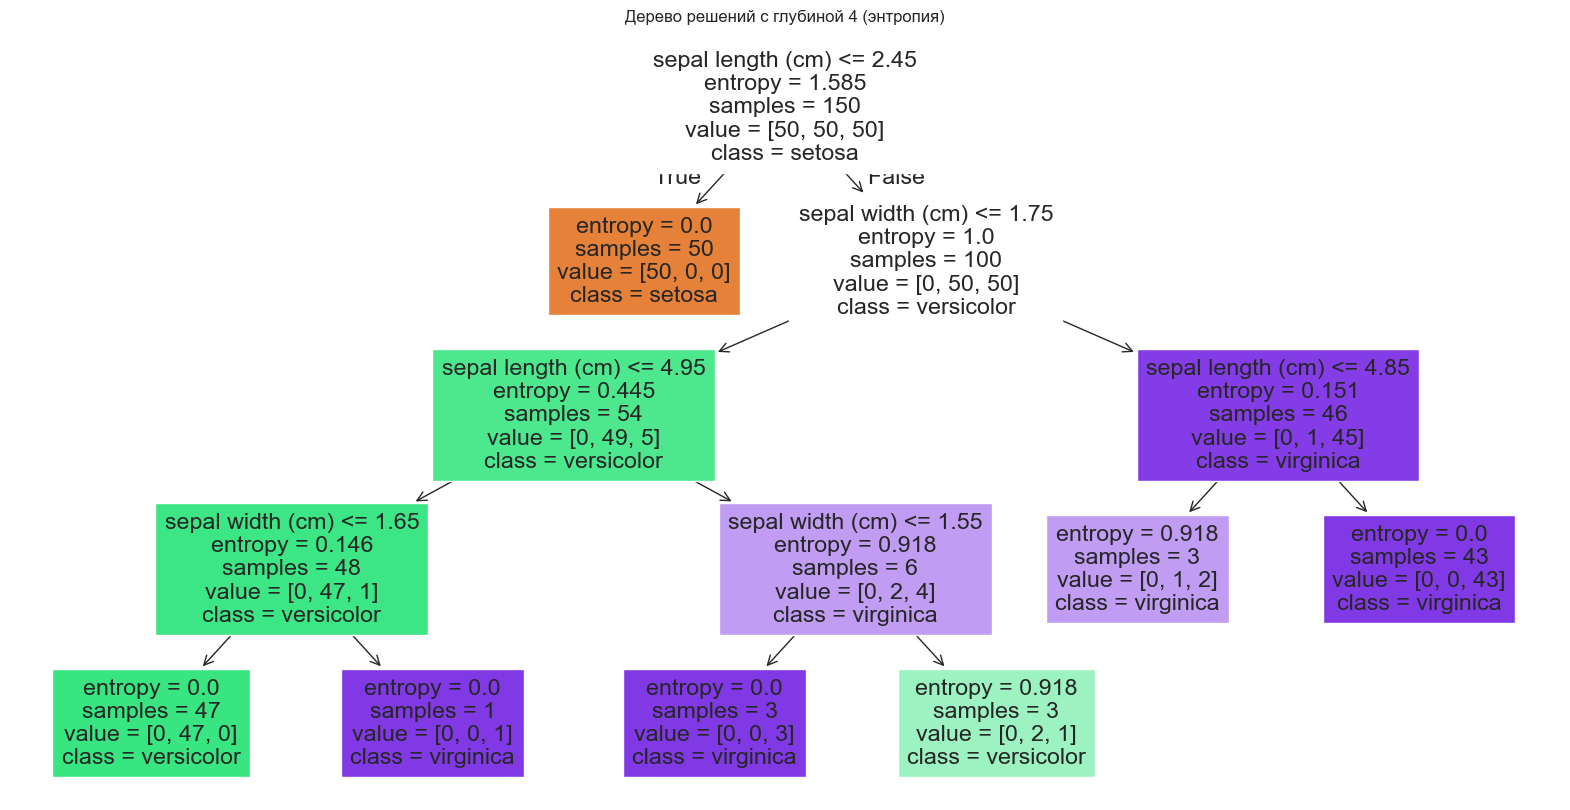

In [26]:
clf = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
clf.fit(X, y)

# Визуализация дерева
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title('Дерево решений с глубиной 4 (энтропия)')
plt.show()

## 3. - 4. Обучение модели дерева с разными глубинами 1, 2, 3, 4, 10; используя энтропию и метрики

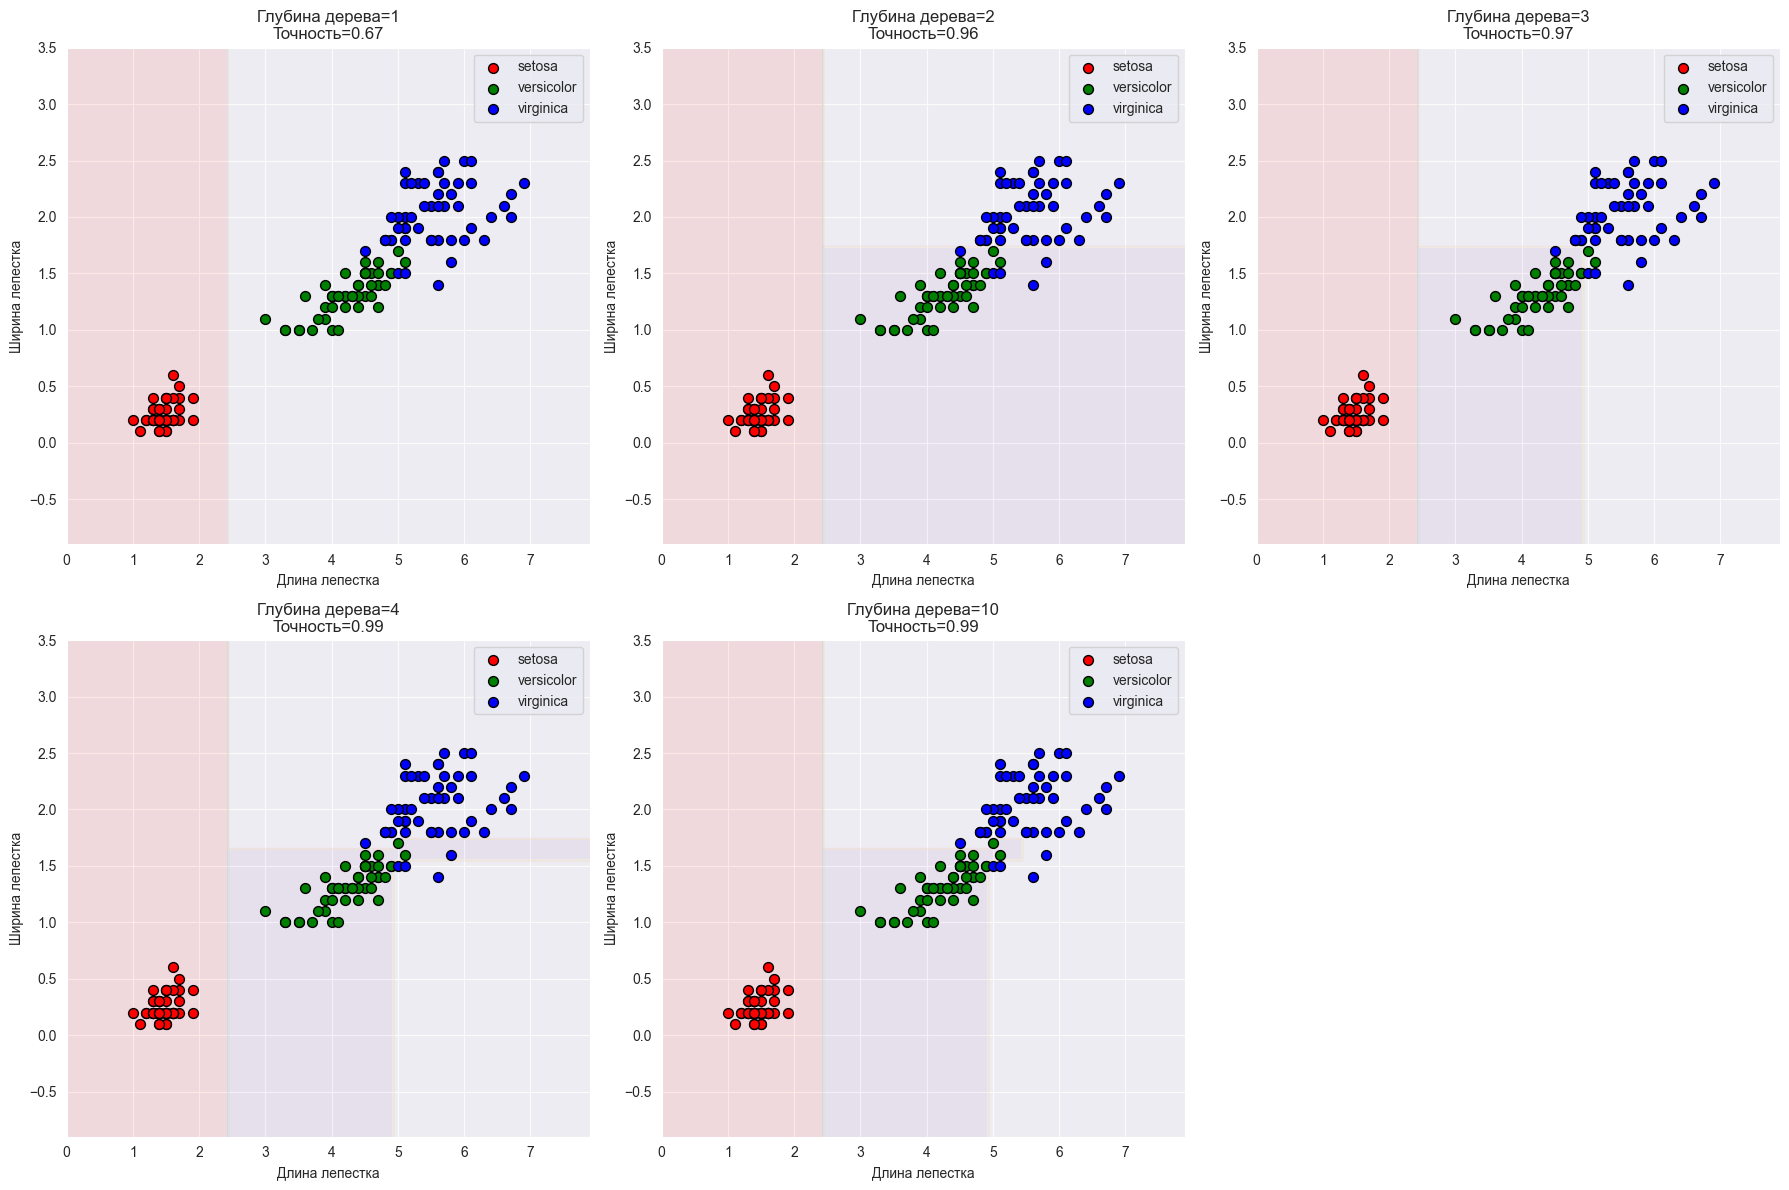

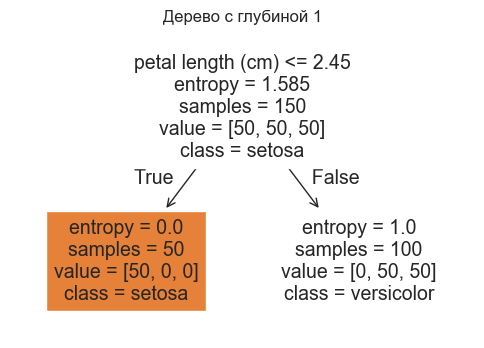


===========================>



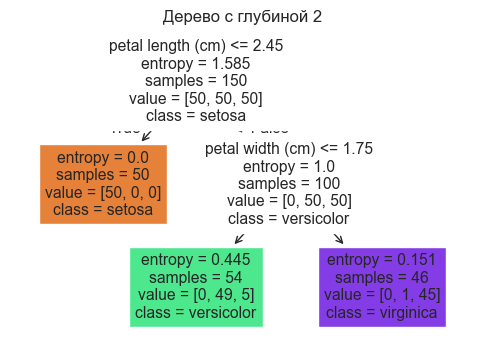


===========================>



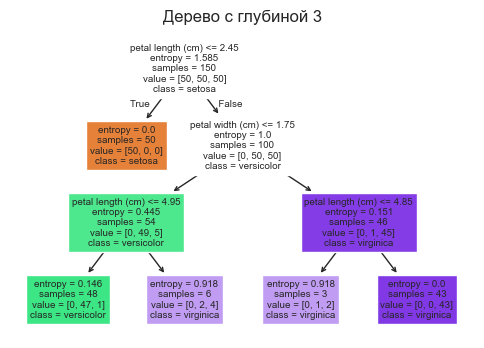


===========================>



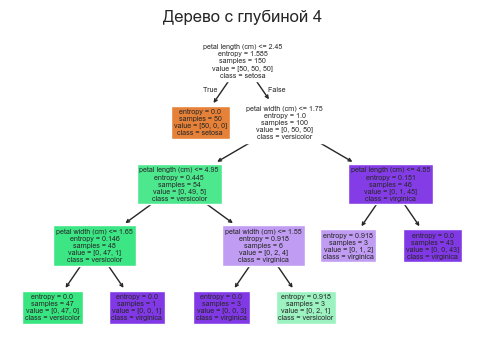


===========================>



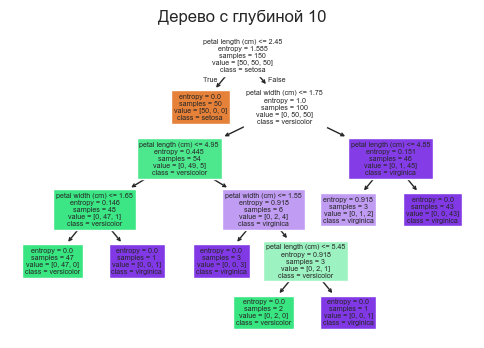


===========================>

Точности моделей с разной глубиной:
Глубина 1: точность = 0.67
Глубина 2: точность = 0.96
Глубина 3: точность = 0.97
Глубина 4: точность = 0.99
Глубина 10: точность = 0.99


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score



# Загружаем данные
iris = load_iris()
X = iris.data[:, 2:]  # длина и ширина лепестков
y = iris.target

# Глубины деревьев
depths = [1, 2, 3, 4, 10]

# Создаем сетку для разделения областей
X0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
X1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)
grid_points = np.c_[X0_grid.ravel(), X1_grid.ravel()]

# Создаем фигуру для разделяющих областей
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

accuracies = []  # список для хранения точностей
models = []

for i, depth in enumerate(depths):
    clf = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    clf.fit(X, y)
    models.append(clf)
    # Предсказания по сетке
    y_pred = clf.predict(grid_points).reshape(X0_grid.shape)

    # Рассчитываем точность на обучающей выборке
    y_train_pred = clf.predict(X)
    acc = accuracy_score(y, y_train_pred)
    accuracies.append(acc)

    # В области
    ax = axes[i]
    ax.contourf(X0_grid, X1_grid, y_pred, alpha=0.3, cmap=plt.cm.Pastel1)
    for cls_idx, color, label in zip([0,1,2], ['red', 'green', 'blue'], iris.target_names):
        ax.scatter(X[y == cls_idx, 0], X[y == cls_idx, 1],
                   label=label, edgecolors='k', s=50, color=color)
    ax.set_title(f'Глубина дерева={depth}\nТочность={acc:.2f}')
    ax.set_xlabel('Длина лепестка')
    ax.set_ylabel('Ширина лепестка')
    ax.legend()

# Удаляем лишние пустые оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Вывод структур деревьев
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    clf.fit(X, y)
    plt.figure(figsize=(6,4))
    plot_tree(clf, feature_names=iris.feature_names[2:], class_names=iris.target_names, filled=True)
    plt.title(f'Дерево с глубиной {depth}')
    plt.show()

    print()
    print("===========================>")
    print()

# Вывод точностей
print("Точности моделей с разной глубиной:")
for depth, acc in zip(depths, accuracies):
    print(f"Глубина {depth}: точность = {acc:.2f}")

Модель дерева с глубиной 1

Точность = 0.667
F1 = 0.667


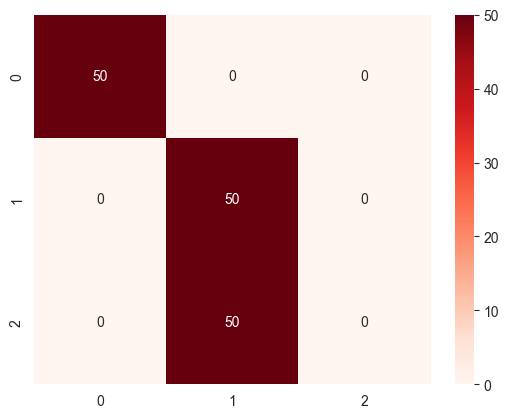

In [39]:
i = 0

y_pred = models[i].predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Reds') # Оси y = true; x = predicted
# TP - FP
# TN - FN

print(f"Модель дерева с глубиной {i+1}")
print()
print('Точность =', round(accuracy_score(y, y_pred), 3))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 3))

Модель дерева с глубиной 2

Точность = 0.96
F1 = 0.96


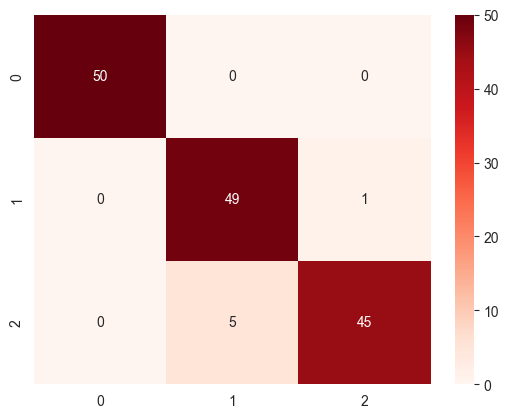

In [40]:
i = 1

y_pred = models[i].predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Reds') # Оси y = true; x = predicted
# TP - FP
# TN - FN

print(f"Модель дерева с глубиной {i+1}")
print()
print('Точность =', round(accuracy_score(y, y_pred), 3))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 3))

Модель дерева с глубиной 3

Точность = 0.973
F1 = 0.973


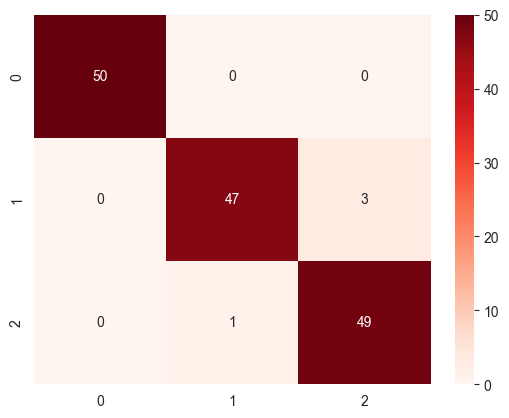

In [41]:
i = 2

y_pred = models[i].predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Reds') # Оси y = true; x = predicted
# TP - FP
# TN - FN

print(f"Модель дерева с глубиной {i+1}")
print()
print('Точность =', round(accuracy_score(y, y_pred), 3))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 3))

Модель дерева с глубиной 4

Точность = 0.987
F1 = 0.987


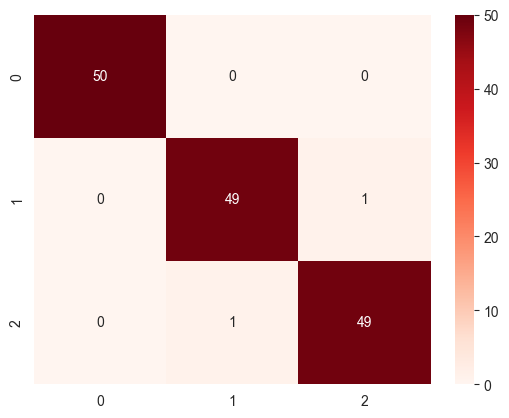

In [42]:
i = 3

y_pred = models[i].predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Reds') # Оси y = true; x = predicted
# TP - FP
# TN - FN

print(f"Модель дерева с глубиной {i+1}")
print()
print('Точность =', round(accuracy_score(y, y_pred), 3))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 3))

Модель дерева с глубиной 10

Точность = 0.993
F1 = 0.993


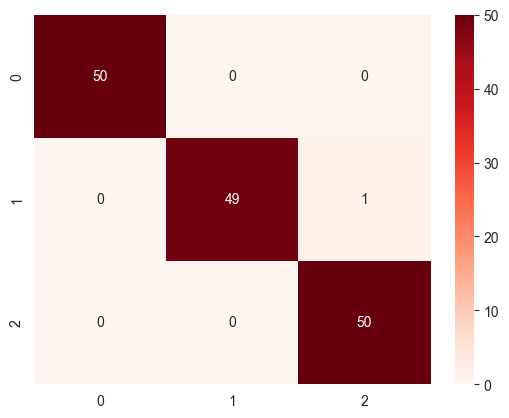

In [43]:
i = 4

y_pred = models[i].predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Reds') # Оси y = true; x = predicted
# TP - FP
# TN - FN

print(f"Модель дерева с глубиной 10")
print()
print('Точность =', round(accuracy_score(y, y_pred), 3))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 3))

## 5. Обучение модели дерева глубиной 4 на всем датасете по энтропии

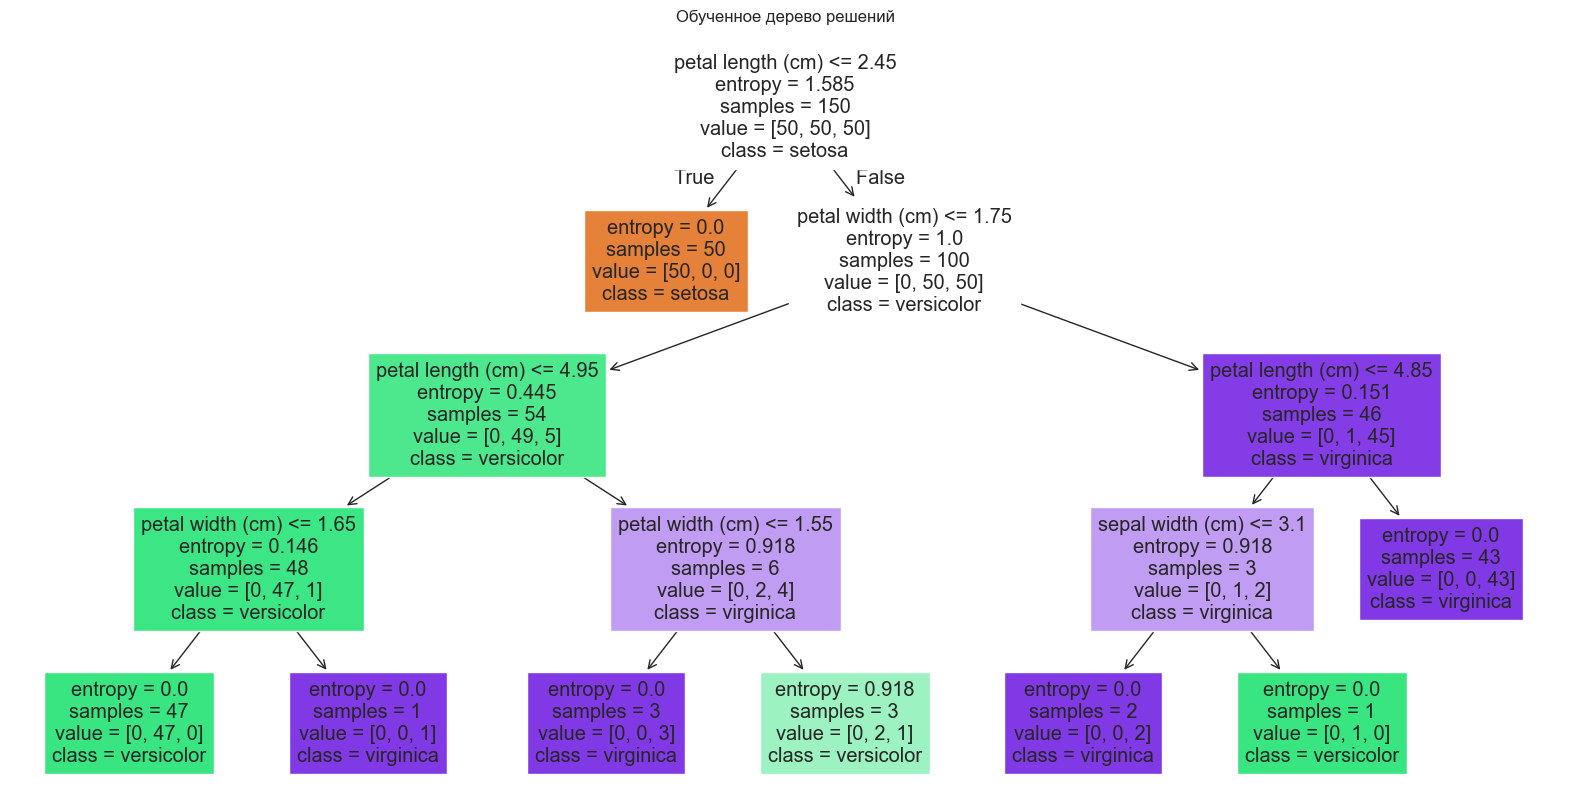

Точность модели: 0.9933


In [46]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

# 2. Обучение дерева
clf = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
clf.fit(X, y)

# 3. Визуализация дерева решений
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Обученное дерево решений")
plt.show()

# 4. Оценка качества
y_pred = clf.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f'Точность модели: {accuracy:.4f}')


Точность = 0.9933
F1 = 0.9933


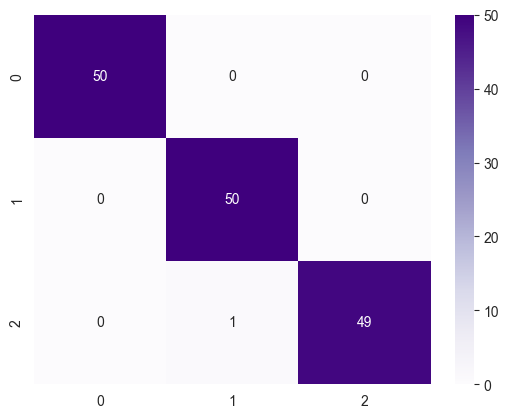

In [48]:
y_pred = clf.predict(X)

sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Purples') # Оси y = true; x = predicted
# TP - FP
# TN - FN
print()
print('Точность =', round(accuracy_score(y, y_pred), 4))
print('F1 =', round(f1_score(y, y_pred, average='micro'), 4))

## 6. Анализ датасета Калифорнийских продажей домов по 1 атрибуту и целевой переменной

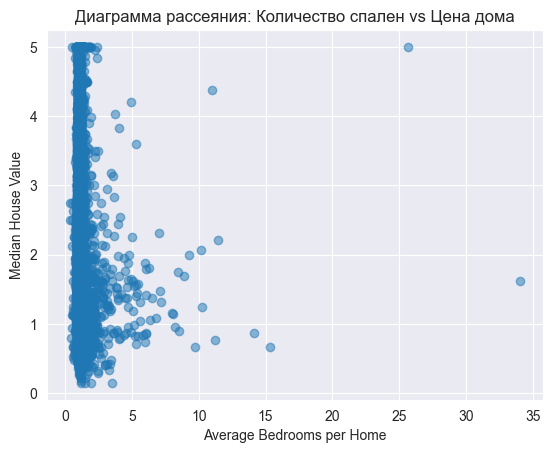

In [49]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Загрузка данных
housing = fetch_california_housing()

# Отбор признака "Average Bedrooms per Home" (AveBedrms)
X = housing.data[:, housing.feature_names.index('AveBedrms')]
y = housing.target  # Целевая переменная - средняя цена дома

# Построение диаграммы рассеяния
plt.scatter(X, y, alpha=0.5)
plt.xlabel('Average Bedrooms per Home')
plt.ylabel('Median House Value')
plt.title('Диаграмма рассеяния: Количество спален vs Цена дома')
plt.show()

## 7. - 8. Обучение модели регрессионного дерева с random_state = 0 и визуализация

Коэффициент детерминации R²: 0.679


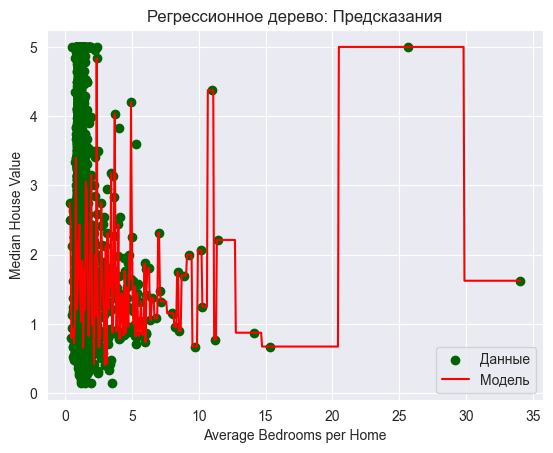

In [55]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
housing = fetch_california_housing()

# Выбор признака "AveBedrms"
X = housing.data[:, housing.feature_names.index('AveBedrms')]
y = housing.target

# Обучение модели
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X.reshape(-1, 1), y)

# Предсказания на обучающих данных
y_pred = regressor.predict(X.reshape(-1, 1))

# Вывод R² (коэффициент детерминации)
r2 = r2_score(y, y_pred)
print(f'Коэффициент детерминации R²: {r2:.3f}')

# Визуализация
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1,1)
y_pred_plot = regressor.predict(X_plot)

plt.scatter(X, y, color='darkgreen', label='Данные')
plt.plot(X_plot, y_pred_plot, color='red', label='Модель')
plt.xlabel('Average Bedrooms per Home')
plt.ylabel('Median House Value')
plt.title('Регрессионное дерево: Предсказания')
plt.legend()
plt.show()

## 9. Создание новой точки и ее предсказание

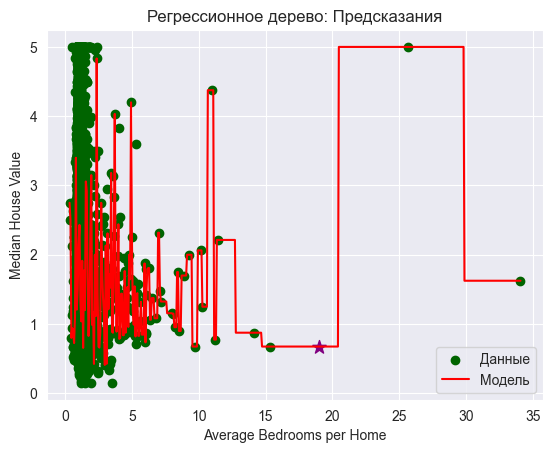

Предсказанная цена для дома с 19 спальнями: 0.675


In [61]:
new = np.array([[19]])

# Сделать предсказание
predicted_price = regressor.predict(new)

plt.scatter(X, y, color='darkgreen', label='Данные')

plt.scatter(new, predicted_price, marker='*', s=100, color='purple')

plt.plot(X_plot, y_pred_plot, color='red', label='Модель')
plt.xlabel('Average Bedrooms per Home')
plt.ylabel('Median House Value')
plt.title('Регрессионное дерево: Предсказания')
plt.legend()
plt.show()
print(f'Предсказанная цена для дома с 19 спальнями: {predicted_price[0]:.3f}')

## 10. Обучение модели теперь на полном датасете

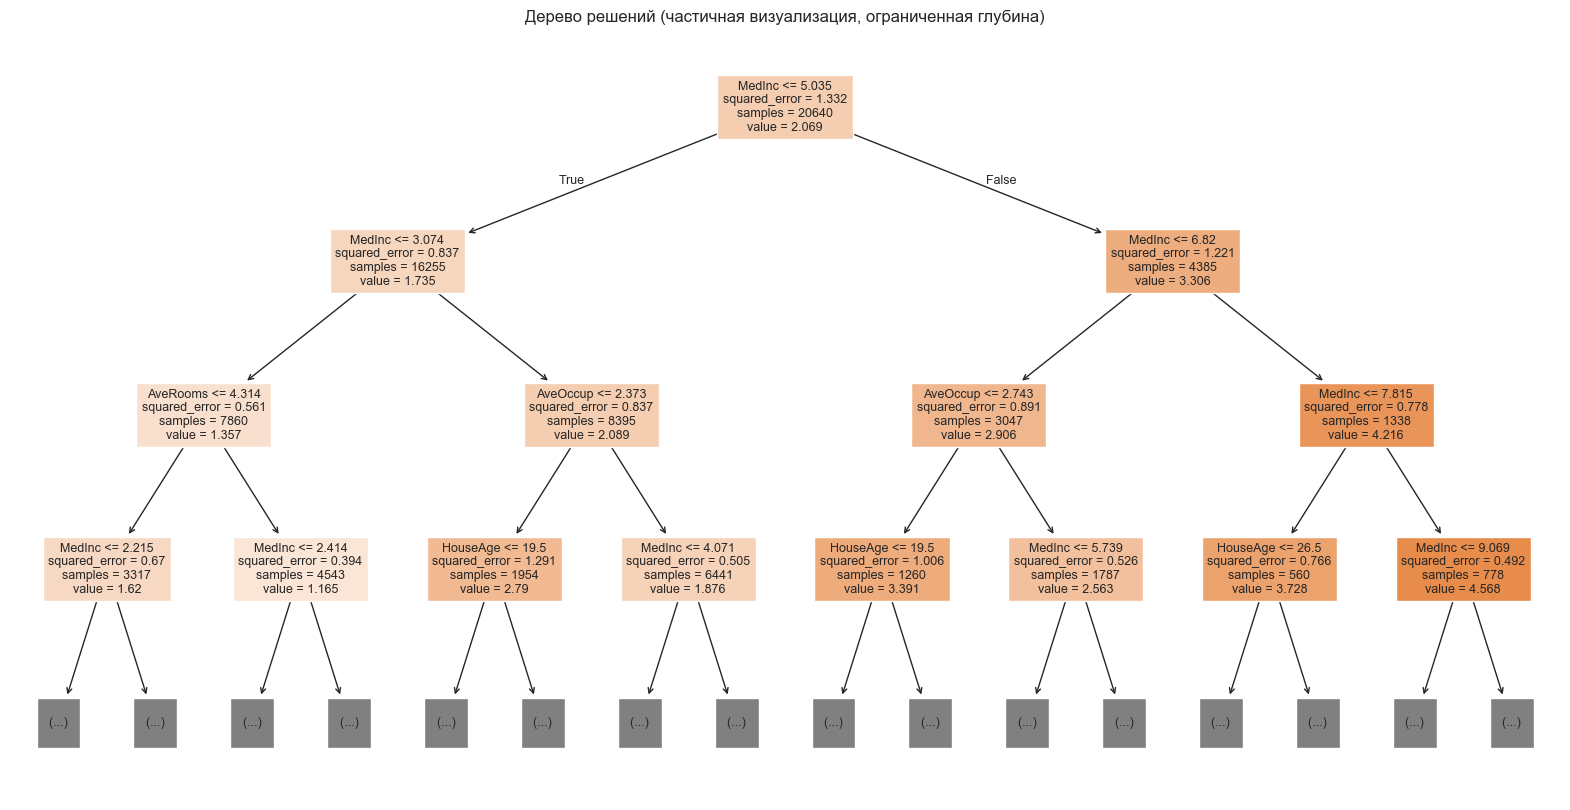

Коэффициент детерминации R²: 1.00000


In [65]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Загрузка всего датасета
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Обучение модели с фиксированным random_state
model = DecisionTreeRegressor(random_state=0)
model.fit(X, y)

# Визуализация дерева решений
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=housing.feature_names, filled=True, max_depth=3, fontsize=9)
plt.title("Дерево решений (частичная визуализация, ограниченная глубина)")
plt.show()

# Оценка качества модели на обучающих данных
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f'Коэффициент детерминации R²: {r2:.5f}')